# Import

In [1]:
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve, recall_score
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import make_pipeline

import lightgbm as lgb


/Users/adrien/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = kagglehub.load_dataset(
KaggleDatasetAdapter.PANDAS,
"mkechinov/ecommerce-behavior-data-from-multi-category-store",
"2019-Oct.csv",
pandas_kwargs={
"nrows": 10_000_000,
"dtype": {
'event_type': 'category',
'product_id': 'int32',
'category_code': 'category',
'brand': 'category',
'price': 'float32',
'user_id': 'int32',
}
}
)

/var/folders/z0/wpl2lwrs3rx3w51w3jxdmvfc0000gp/T/ipykernel_54040/1155051505.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [3]:
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d
...,...,...,...,...,...,...,...,...,...
9999995,2019-10-08 17:26:09 UTC,view,22900082,2053013561780732677,furniture.bedroom.pillow,belashoff,25.740000,518471106,708497d0-bed7-476b-af47-66ebda1d6c68
9999996,2019-10-08 17:26:09 UTC,view,32100001,2060237588744111062,NaN,NaN,164.100006,514437524,f8fc5c52-ae97-4a64-b6f4-fa3f5f9f28df
9999997,2019-10-08 17:26:09 UTC,view,26400265,2053013563651392361,NaN,lucente,154.190002,547749418,e22d0270-8dea-4cc1-ae99-e78a581f515e
9999998,2019-10-08 17:26:09 UTC,view,1005125,2053013555631882655,electronics.smartphone,apple,1955.010010,555334348,28b16eb3-1362-4806-8f4f-0265c7afe096


# EDA/Cleaning

In [4]:
# Verify temporal range
print(df['event_time'].min(), df['event_time'].max())

2019-10-01 00:00:00 UTC 2019-10-08 17:26:09 UTC


In [5]:
df['event_type'].value_counts(normalize=True)

event_type
view        0.962782
cart        0.019935
purchase    0.017283
Name: proportion, dtype: float64

This specific retailer doesn't use remove_from_cart event. They are using override cart mechanics in API. So you can figured out removed from cart products as difference between purchase and cart events.

In [6]:
df['category_id'].nunique()

566

In [7]:
df['product_id'].nunique()

121903

In [8]:
df['category_code'].nunique()

123

In [9]:
#Clean the event time, remove UTC

df["event_time"] = pd.to_datetime(
    df["event_time"].str.replace(" UTC", "", regex=False),
    format="%Y-%m-%d %H:%M:%S",
)

In [10]:
# Stats descriptives (colonnes numériques)
df.describe()

,event_time,product_id,category_id,price,user_id
count,10000000,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07
mean,2019-10-04 23:35:08.081178368,1.011534e+07,2.056684e+18,2.960614e+02,5.317569e+08
min,2019-10-01 00:00:00,1.001588e+06,2.053014e+18,0.000000e+00,1.835035e+08
25%,2019-10-03 03:22:41,1.005115e+06,2.053014e+18,6.525000e+01,5.156193e+08
50%,2019-10-05 01:32:45,4.900087e+06,2.053014e+18,1.619100e+02,5.274672e+08
75%,2019-10-06 18:21:33,1.570007e+07,2.053014e+18,3.618200e+02,5.487683e+08
max,2019-10-08 17:26:09,5.560003e+07,2.175420e+18,2.574070e+03,5.581647e+08
std,NaN,1.124471e+07,1.681746e+16,3.669100e+02,1.715918e+07


In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing': missing, '%': missing_pct}).query('missing > 0').sort_values('%', ascending=False)

,missing,%
category_code,3224119,32.2
brand,1388005,13.9
user_session,1,0.0


In [12]:
df['user_id'].nunique()

1070614

In [13]:
df_purchase = df.groupby('category_code')['event_type'].apply(lambda x: (x == 'purchase').sum())

/var/folders/z0/wpl2lwrs3rx3w51w3jxdmvfc0000gp/T/ipykernel_54040/985662042.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_purchase = df.groupby('category_code')['event_type'].apply(lambda x: (x == 'purchase').sum())


In [14]:
df_purchase.sort_values(ascending=False)

category_code
electronics.smartphone           79205
electronics.audio.headphone       7257
electronics.video.tv              4849
electronics.clocks                4495
computers.notebook                3914
                                 ...  
country_yard.furniture.bench         0
country_yard.furniture.hammok        0
apparel.dress                        0
apparel.jacket                       0
sport.tennis                         0
Name: event_type, Length: 123, dtype: int64

In [15]:
(df_purchase / df_purchase.sum() * 100).sort_values(ascending=False)

category_code
electronics.smartphone           59.461428
electronics.audio.headphone       5.448035
electronics.video.tv              3.640281
electronics.clocks                3.374523
computers.notebook                2.938350
                                   ...    
country_yard.furniture.bench      0.000000
country_yard.furniture.hammok     0.000000
apparel.dress                     0.000000
apparel.jacket                    0.000000
sport.tennis                      0.000000
Name: event_type, Length: 123, dtype: float64

In [16]:
# Lister les catégories à 0 achats
df_purchase[df_purchase == 0].index.tolist()
# Combien il y en a
(df_purchase == 0).sum()

np.int64(7)

In [17]:
# Catégories avec au moins 1 achat
df_purchase_clean = df_purchase[df_purchase > 0].sort_values(ascending=False)
df_purchase_clean

category_code
electronics.smartphone         79205
electronics.audio.headphone     7257
electronics.video.tv            4849
electronics.clocks              4495
computers.notebook              3914
                               ...  
apparel.scarf                      2
apparel.shoes.sandals              2
apparel.shorts                     2
apparel.shoes.ballet_shoes         1
apparel.skirt                      1
Name: event_type, Length: 116, dtype: int64

In [18]:
df["brand"] = df["brand"].astype(str).replace("nan", "unknown").astype("category")
df["has_brand"] = (df["brand"] != "unknown").astype("int8")

In [19]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing': missing, '%': missing_pct}).query('missing > 0').sort_values('%', ascending=False)

,missing,%
category_code,3224119,32.2
user_session,1,0.0


In [20]:
df = df.drop_duplicates()

In [21]:
n_bad_price = (df["price"] <= 0).sum()

In [22]:
n_bad_price

np.int64(15522)

In [23]:
df["has_valid_price"] = (df["price"] > 0).astype("int8")

/var/folders/z0/wpl2lwrs3rx3w51w3jxdmvfc0000gp/T/ipykernel_54040/3154629573.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["has_valid_price"] = (df["price"] > 0).astype("int8")


In [24]:
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price
0,2019-10-01 00:00:00,view,44600062,2103807459595387724,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c,1,1
1,2019-10-01 00:00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,1,1
2,2019-10-01 00:00:01,view,17200506,2053013559792632471,furniture.living_room.sofa,unknown,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,0,1
3,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,1
4,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,1
...,...,...,...,...,...,...,...,...,...,...,...
9999995,2019-10-08 17:26:09,view,22900082,2053013561780732677,furniture.bedroom.pillow,belashoff,25.740000,518471106,708497d0-bed7-476b-af47-66ebda1d6c68,1,1
9999996,2019-10-08 17:26:09,view,32100001,2060237588744111062,NaN,unknown,164.100006,514437524,f8fc5c52-ae97-4a64-b6f4-fa3f5f9f28df,0,1
9999997,2019-10-08 17:26:09,view,26400265,2053013563651392361,NaN,lucente,154.190002,547749418,e22d0270-8dea-4cc1-ae99-e78a581f515e,1,1
9999998,2019-10-08 17:26:09,view,1005125,2053013555631882655,electronics.smartphone,apple,1955.010010,555334348,28b16eb3-1362-4806-8f4f-0265c7afe096,1,1


# Preprocessing X, y

## Filtering X to keep only top 5 category_code

In [25]:
top5 = ['electronics.smartphone', 'electronics.audio.headphone', 'electronics.video.tv',
        'electronics.clocks', 'computers.notebook']

X = df[df['category_code'].isin(top5)]

In [26]:
X

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price
3,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,1
4,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,1
9,2019-10-01 00:00:11,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb,1,1
11,2019-10-01 00:00:11,view,1005011,2053013555631882655,electronics.smartphone,samsung,900.640015,530282093,50a293fb-5940-41b2-baf3-17af0e812101,1,1
16,2019-10-01 00:00:18,view,1801995,2053013554415534427,electronics.video.tv,haier,193.029999,537192226,e3151795-c355-4efa-acf6-e1fe1bebeee5,1,1
...,...,...,...,...,...,...,...,...,...,...,...
9999984,2019-10-08 17:26:08,view,1005105,2053013555631882655,electronics.smartphone,apple,1415.479980,512565865,4f98f4f3-60da-48aa-bc71-0d39b2eba526,1,1
9999985,2019-10-08 17:26:08,view,1307383,2053013558920217191,computers.notebook,asus,1282.140015,513451334,c2f51343-7977-4ac3-ae5a-5e274918310e,1,1
9999987,2019-10-08 17:26:08,view,1307293,2053013558920217191,computers.notebook,msi,866.710022,513956748,fdf662f6-e9a4-4991-9d2e-a8b5b6073441,1,1
9999989,2019-10-08 17:26:08,view,1004433,2053013555631882655,electronics.smartphone,samsung,257.149994,512963963,b61ab7c6-2a1a-4ef2-9e1d-1fa9b288fe9b,1,1


In [27]:
X = X.drop_duplicates()
# Il reste 35% des lignes, donc 1/3 des events sont compris sur ces 5 catégories

In [28]:
missing = X.isnull().sum()
missing_pct = (missing / len(X) * 100).round(1)
pd.DataFrame({'missing': missing, '%': missing_pct}).query('missing > 0').sort_values('%', ascending=False)

,missing,%
user_session,1,0.0


In [29]:
X = X.sort_values("event_time").reset_index(drop=True)

In [30]:
X

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price
0,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,1
1,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,1
2,2019-10-01 00:00:11,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb,1,1
3,2019-10-01 00:00:11,view,1005011,2053013555631882655,electronics.smartphone,samsung,900.640015,530282093,50a293fb-5940-41b2-baf3-17af0e812101,1,1
4,2019-10-01 00:00:18,view,1801995,2053013554415534427,electronics.video.tv,haier,193.029999,537192226,e3151795-c355-4efa-acf6-e1fe1bebeee5,1,1
...,...,...,...,...,...,...,...,...,...,...,...
3857586,2019-10-08 17:26:08,view,21409279,2053013561579406073,electronics.clocks,casio,45.820000,544509415,021a0c6e-570c-4bb0-a338-bbe58a197075,1,1
3857587,2019-10-08 17:26:08,view,1005105,2053013555631882655,electronics.smartphone,apple,1415.479980,512565865,4f98f4f3-60da-48aa-bc71-0d39b2eba526,1,1
3857588,2019-10-08 17:26:08,view,1307383,2053013558920217191,computers.notebook,asus,1282.140015,513451334,c2f51343-7977-4ac3-ae5a-5e274918310e,1,1
3857589,2019-10-08 17:26:08,view,1307293,2053013558920217191,computers.notebook,msi,866.710022,513956748,fdf662f6-e9a4-4991-9d2e-a8b5b6073441,1,1


## Set Observation and prediction period for X

In [31]:

observation_end = pd.Timestamp("2019-10-05")
prediction_end  = pd.Timestamp("2019-10-08")

In [32]:
X_obs = X[X["event_time"] < observation_end].copy()
X_pred = X[X["event_time"] >= observation_end].copy()

In [33]:
X_obs

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price
0,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,1
1,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,1
2,2019-10-01 00:00:11,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb,1,1
3,2019-10-01 00:00:11,view,1005011,2053013555631882655,electronics.smartphone,samsung,900.640015,530282093,50a293fb-5940-41b2-baf3-17af0e812101,1,1
4,2019-10-01 00:00:18,view,1801995,2053013554415534427,electronics.video.tv,haier,193.029999,537192226,e3151795-c355-4efa-acf6-e1fe1bebeee5,1,1
...,...,...,...,...,...,...,...,...,...,...,...
1984046,2019-10-04 23:59:54,cart,1002547,2053013555631882655,electronics.smartphone,apple,461.140015,521536317,1c999493-a6bf-448f-8bd6-04ad1f22d265,1,1
1984047,2019-10-04 23:59:55,view,1002544,2053013555631882655,electronics.smartphone,apple,462.410004,556879570,915fdc40-9027-4cec-a71e-01f78874fd4b,1,1
1984048,2019-10-04 23:59:56,view,1004993,2053013555631882655,electronics.smartphone,oneplus,591.750000,556398081,5edc4b5c-bf0e-45bf-84f5-a7354f2df473,1,1
1984049,2019-10-04 23:59:57,view,1004253,2053013555631882655,electronics.smartphone,apple,810.719971,556879664,acda6a98-2ec1-4e8e-b38d-0dbbe7fb1f04,1,1


In [34]:
X_pred

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price
1984051,2019-10-05 00:00:00,view,1004957,2053013555631882655,electronics.smartphone,xiaomi,348.119995,555865719,4266918c-801d-48f7-bd76-b6833e5435ba,1,1
1984052,2019-10-05 00:00:00,view,4804056,2053013554658804075,electronics.audio.headphone,apple,161.839996,524936559,5089b23e-57c6-4f2e-bac2-027610ce89c3,1,1
1984053,2019-10-05 00:00:01,view,1003965,2053013555631882655,electronics.smartphone,samsung,720.460022,522523232,a92123e7-68f9-47bd-9b13-ee11db579c7f,1,1
1984054,2019-10-05 00:00:04,view,1004741,2053013555631882655,electronics.smartphone,xiaomi,185.800003,515531327,84681089-8368-4a84-b30b-1996b40d9884,1,1
1984055,2019-10-05 00:00:05,view,1005115,2053013555631882655,electronics.smartphone,apple,975.559998,545662171,0b1b71ae-7632-46f7-a2b2-20fe696c3a46,1,1
...,...,...,...,...,...,...,...,...,...,...,...
3857586,2019-10-08 17:26:08,view,21409279,2053013561579406073,electronics.clocks,casio,45.820000,544509415,021a0c6e-570c-4bb0-a338-bbe58a197075,1,1
3857587,2019-10-08 17:26:08,view,1005105,2053013555631882655,electronics.smartphone,apple,1415.479980,512565865,4f98f4f3-60da-48aa-bc71-0d39b2eba526,1,1
3857588,2019-10-08 17:26:08,view,1307383,2053013558920217191,computers.notebook,asus,1282.140015,513451334,c2f51343-7977-4ac3-ae5a-5e274918310e,1,1
3857589,2019-10-08 17:26:08,view,1307293,2053013558920217191,computers.notebook,msi,866.710022,513956748,fdf662f6-e9a4-4991-9d2e-a8b5b6073441,1,1


## Create y with purchasers from prediction period

In [35]:
purchasers = set(X_pred.loc[X_pred["event_type"] == "purchase", "user_id"])


In [36]:
len(purchasers)

30983

In [37]:
#Dataframe avec tous les users_id unique de X_pred
y_purchasers = pd.DataFrame({"user_id": X_pred["user_id"].unique()})

#Création d'une colonne label qui transforme les user_id en 1 et 0 s'ils ont acheté sur la période ou non
y_purchasers["label"] = y_purchasers["user_id"].isin(purchasers).astype(int)

In [38]:
y_purchasers["label"].value_counts()
# Sur X_obs, env. 2 500 000 events sont enregistrés pour 375 000 utilisateurs unique, avec 9300 qui achèteront sur l'intervalle d'observation

label
0    265182
1     30983
Name: count, dtype: int64

In [39]:
y_purchasers

,user_id,label
0,555865719,0
1,524936559,1
2,522523232,1
3,515531327,0
4,545662171,0
...,...,...
296160,558164653,0
296161,540043928,0
296162,535605942,0
296163,553196819,0


## Create y with purchasers from observation period

In [40]:
# Set avec tous les users_id qui ont acheté pendant X_obs
purchasers_x_obs = set(X_obs.loc[X_obs["event_type"] == "purchase", "user_id"])

#Dataframe avec tous les users_id unique de X_obs
y_purchasers_x_obs = pd.DataFrame({"user_id": X_obs["user_id"].unique()})

#Création d'une colonne label qui transforme les user_id en 1 et 0 s'ils ont acheté sur la période ou non
y_purchasers_x_obs["label"] = y_purchasers_x_obs["user_id"].isin(purchasers_x_obs).astype(int)

y_purchasers_x_obs

,user_id,label
0,550050854,0
1,535871217,0
2,537918940,0
3,530282093,0
4,537192226,0
...,...,...
311289,521099214,0
311290,556879729,0
311291,556879612,0
311292,556872550,0


# Feature engineering X_obs

## Global Features creation per user, for the observation period(behavior df)

In [41]:
X_obs["hour"] = X_obs["event_time"].dt.hour
X_obs["dayofweek"] = X_obs["event_time"].dt.dayofweek  # 0=Lundi
X_obs["is_weekend"] = (X_obs["dayofweek"] >= 5).astype("int8")


In [42]:
X_obs

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price,hour,dayofweek,is_weekend
0,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,1,0,1,0
1,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,1,0,1,0
2,2019-10-01 00:00:11,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb,1,1,0,1,0
3,2019-10-01 00:00:11,view,1005011,2053013555631882655,electronics.smartphone,samsung,900.640015,530282093,50a293fb-5940-41b2-baf3-17af0e812101,1,1,0,1,0
4,2019-10-01 00:00:18,view,1801995,2053013554415534427,electronics.video.tv,haier,193.029999,537192226,e3151795-c355-4efa-acf6-e1fe1bebeee5,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1984046,2019-10-04 23:59:54,cart,1002547,2053013555631882655,electronics.smartphone,apple,461.140015,521536317,1c999493-a6bf-448f-8bd6-04ad1f22d265,1,1,23,4,0
1984047,2019-10-04 23:59:55,view,1002544,2053013555631882655,electronics.smartphone,apple,462.410004,556879570,915fdc40-9027-4cec-a71e-01f78874fd4b,1,1,23,4,0
1984048,2019-10-04 23:59:56,view,1004993,2053013555631882655,electronics.smartphone,oneplus,591.750000,556398081,5edc4b5c-bf0e-45bf-84f5-a7354f2df473,1,1,23,4,0
1984049,2019-10-04 23:59:57,view,1004253,2053013555631882655,electronics.smartphone,apple,810.719971,556879664,acda6a98-2ec1-4e8e-b38d-0dbbe7fb1f04,1,1,23,4,0


In [43]:
behavior = X_obs.groupby("user_id").agg(
    total_events   = ("event_type", "count"),
    total_views    = ("event_type", lambda x: (x == "view").sum()),
    total_carts    = ("event_type", lambda x: (x == "cart").sum()),
    total_purchases= ("event_type", lambda x: (x == "purchase").sum()),
    n_sessions     = ("user_session", "nunique"),
    n_days_active  = ("event_time", lambda x: x.dt.date.nunique()),
)

# Features de comportement dans l'intervalle d'observation choisi
# Prend beaucoup de temps les fonctions lambda, optimisable?

In [44]:
behavior

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active
user_id,,,,,,
241587569,1,1,0,0,1,1
241784978,1,1,0,0,1,1
244951053,5,5,0,0,2,2
293335683,12,12,0,0,3,1
293957954,4,4,0,0,1,1
...,...,...,...,...,...,...
556879570,5,5,0,0,1,1
556879574,3,3,0,0,1,1
556879612,1,1,0,0,1,1


In [45]:
behavior["has_ever_carted"] = (behavior["total_carts"] > 0).astype("int8")
behavior["has_ever_purchased"] = (behavior["total_purchases"] > 0).astype("int8")


In [46]:
behavior["has_ever_carted"].value_counts(normalize=True)

has_ever_carted
0    0.887319
1    0.112681
Name: proportion, dtype: float64

In [47]:
behavior["has_ever_purchased"].value_counts(normalize=True)

has_ever_purchased
0    0.898414
1    0.101586
Name: proportion, dtype: float64

In [48]:
behavior["view_to_cart_ratio"] = (
    behavior["total_carts"] / behavior["total_views"].replace(0, 1)
)
behavior["cart_to_purchase_ratio"] = (
    behavior["total_purchases"] / behavior["total_carts"].replace(0, 1)
)

#Est-ce que c'est des bonnes features? L'info est peut-être déjà présente

In [49]:
behavior

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio
user_id,,,,,,,,,,
241587569,1,1,0,0,1,1,0,0,0.0,0.0
241784978,1,1,0,0,1,1,0,0,0.0,0.0
244951053,5,5,0,0,2,2,0,0,0.0,0.0
293335683,12,12,0,0,3,1,0,0,0.0,0.0
293957954,4,4,0,0,1,1,0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
556879570,5,5,0,0,1,1,0,0,0.0,0.0
556879574,3,3,0,0,1,1,0,0,0.0,0.0
556879612,1,1,0,0,1,1,0,0,0.0,0.0


In [50]:
behavior["cart_to_purchase_ratio"].value_counts(ascending=False)

cart_to_purchase_ratio
0.000000     279671
1.000000      19259
0.500000       3467
2.000000       2398
0.333333       1363
              ...  
2.375000          1
0.823529          1
2.800000          1
15.000000         1
0.521739          1
Name: count, Length: 223, dtype: int64

## Session features creation(session_stats, long_session_user df)

In [51]:
session_stats = X_obs.groupby(["user_id", "user_session"], as_index=False).agg(
    session_start = ("event_time", "min"),
    session_end   = ("event_time", "max"),
    session_events = ("event_time", "count"),
)

In [52]:
session_stats

,user_id,user_session,session_start,session_end,session_events
0,241587569,8a09b6c6-07e6-4f80-ae22-a6b400fc7894,2019-10-02 11:28:14,2019-10-02 11:28:14,1
1,241784978,db17076d-5be1-4f1e-acd1-a2baf23eb3fd,2019-10-04 08:00:07,2019-10-04 08:00:07,1
2,244951053,91769fdf-461b-4e43-9c73-88a07481b75c,2019-10-01 08:47:35,2019-10-01 08:48:28,2
3,244951053,ac5e27ca-6408-47ab-9837-19893a0334c2,2019-10-03 03:06:18,2019-10-03 03:08:27,3
4,293335683,181dcd66-f81e-4e95-9621-1fa9e31944c4,2019-10-02 17:55:58,2019-10-02 18:00:33,3
...,...,...,...,...,...
507178,556879570,915fdc40-9027-4cec-a71e-01f78874fd4b,2019-10-04 23:58:12,2019-10-04 23:59:55,5
507179,556879574,558d44cd-35b9-4d3a-95b6-58717c2440ca,2019-10-04 23:58:29,2019-10-04 23:59:34,3
507180,556879612,5fcfb11f-bde5-414c-a42a-9a8398a9b6e3,2019-10-04 23:59:11,2019-10-04 23:59:11,1
507181,556879664,acda6a98-2ec1-4e8e-b38d-0dbbe7fb1f04,2019-10-04 23:59:03,2019-10-04 23:59:57,2


In [53]:
session_stats["user_id"].nunique()
# Environ 2 sessions par user_id

311294

In [54]:
session_stats["session_duration"] = (
    session_stats["session_end"] - session_stats["session_start"]
)

In [55]:
# Filtrer les sessions de 18h ou plus
long_sessions = session_stats[session_stats['session_duration'] >= pd.Timedelta(hours=18)]

# Créer un dataframe avec les user_id concernés
long_session_users = long_sessions[['user_id']].drop_duplicates().reset_index(drop=True)

In [56]:
long_session_users

,user_id
0,340041246
1,390634364
2,404602614
3,408858428
4,414175028
...,...
1103,556392108
1104,556395156
1105,556395663
1106,556435739


In [57]:
session_stats = session_stats[session_stats['session_duration'] < pd.Timedelta(hours=18)]
session_stats


,user_id,user_session,session_start,session_end,session_events,session_duration
0,241587569,8a09b6c6-07e6-4f80-ae22-a6b400fc7894,2019-10-02 11:28:14,2019-10-02 11:28:14,1,0 days 00:00:00
1,241784978,db17076d-5be1-4f1e-acd1-a2baf23eb3fd,2019-10-04 08:00:07,2019-10-04 08:00:07,1,0 days 00:00:00
2,244951053,91769fdf-461b-4e43-9c73-88a07481b75c,2019-10-01 08:47:35,2019-10-01 08:48:28,2,0 days 00:00:53
3,244951053,ac5e27ca-6408-47ab-9837-19893a0334c2,2019-10-03 03:06:18,2019-10-03 03:08:27,3,0 days 00:02:09
4,293335683,181dcd66-f81e-4e95-9621-1fa9e31944c4,2019-10-02 17:55:58,2019-10-02 18:00:33,3,0 days 00:04:35
...,...,...,...,...,...,...
507178,556879570,915fdc40-9027-4cec-a71e-01f78874fd4b,2019-10-04 23:58:12,2019-10-04 23:59:55,5,0 days 00:01:43
507179,556879574,558d44cd-35b9-4d3a-95b6-58717c2440ca,2019-10-04 23:58:29,2019-10-04 23:59:34,3,0 days 00:01:05
507180,556879612,5fcfb11f-bde5-414c-a42a-9a8398a9b6e3,2019-10-04 23:59:11,2019-10-04 23:59:11,1,0 days 00:00:00
507181,556879664,acda6a98-2ec1-4e8e-b38d-0dbbe7fb1f04,2019-10-04 23:59:03,2019-10-04 23:59:57,2,0 days 00:00:54


## EDA Session leading to purchase(df_purchase_sessions)

In [58]:
df_purchasers = pd.DataFrame({"user_id": X_pred.loc[X_pred["event_type"] == "purchase", "user_id"]})
# Sort les purchasers de la période prédictive, avec plusieurs achats par user_id
df_purchasers["session_with_purchase"] = X_pred.loc[X_pred["event_type"] == "purchase", "user_session"]

In [59]:
df_purchasers

,user_id,session_with_purchase
1984069,521536317,1c999493-a6bf-448f-8bd6-04ad1f22d265
1984131,522523232,a92123e7-68f9-47bd-9b13-ee11db579c7f
1984134,524936559,5089b23e-57c6-4f2e-bac2-027610ce89c3
1984135,546781923,d7ca675f-d3d8-4e36-8a07-830dd9d472dc
1984177,518659039,38ca9e91-e706-4fe1-bb01-dc0c80813739
...,...,...
3857011,536591421,98d78207-bf49-4105-8f7b-ec1f07e72df0
3857079,534262103,c2cb4830-9269-4486-b74e-ed98f8addac2
3857239,514726585,45a46572-4fae-4a58-b8d4-e4ca99f5878e
3857489,536591421,98d78207-bf49-4105-8f7b-ec1f07e72df0


In [60]:
session_stats_full = (
    X.groupby(["user_id", "user_session"], as_index=False)
    .agg(
        session_start=("event_time", "min"),
        session_end=("event_time", "max"),
        session_events=("event_time", "count"),
    )
)

session_stats_full["session_duration"] = (
    session_stats_full["session_end"] -
    session_stats_full["session_start"]
)

df_purchase_sessions = df_purchasers.merge(
    session_stats_full,
    left_on="session_with_purchase",
    right_on="user_session",
    how="left"
)

# Nettoyer
df_purchase_sessions = (
    df_purchase_sessions
    .drop(columns=["user_id_y", "user_session"])
    .rename(columns={"user_id_x": "user_id"})
)

In [61]:
df_purchase_sessions

,user_id,session_with_purchase,session_start,session_end,session_events,session_duration
0,521536317,1c999493-a6bf-448f-8bd6-04ad1f22d265,2019-10-04 23:57:22,2019-10-05 00:04:54,16,0 days 00:07:32
1,522523232,a92123e7-68f9-47bd-9b13-ee11db579c7f,2019-10-04 23:57:18,2019-10-05 00:05:36,13,0 days 00:08:18
2,524936559,5089b23e-57c6-4f2e-bac2-027610ce89c3,2019-10-04 23:57:30,2019-10-05 00:02:09,7,0 days 00:04:39
3,546781923,d7ca675f-d3d8-4e36-8a07-830dd9d472dc,2019-10-04 23:56:49,2019-10-05 00:05:00,11,0 days 00:08:11
4,518659039,38ca9e91-e706-4fe1-bb01-dc0c80813739,2019-10-04 23:56:52,2019-10-05 00:03:10,5,0 days 00:06:18
...,...,...,...,...,...,...
49165,536591421,98d78207-bf49-4105-8f7b-ec1f07e72df0,2019-10-08 17:23:06,2019-10-08 17:25:57,4,0 days 00:02:51
49166,534262103,c2cb4830-9269-4486-b74e-ed98f8addac2,2019-10-08 17:20:04,2019-10-08 17:25:52,4,0 days 00:05:48
49167,514726585,45a46572-4fae-4a58-b8d4-e4ca99f5878e,2019-10-08 17:25:06,2019-10-08 17:25:30,2,0 days 00:00:24
49168,536591421,98d78207-bf49-4105-8f7b-ec1f07e72df0,2019-10-08 17:23:06,2019-10-08 17:25:57,4,0 days 00:02:51


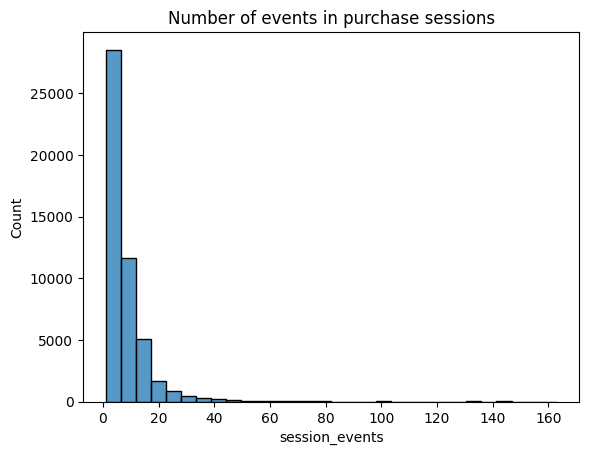

In [62]:
# Distribution des évènements dans la session d'achat

sns.histplot(df_purchase_sessions["session_events"], bins=30)

plt.title("Number of events in purchase sessions")
plt.show()

In [63]:
df_purchase_sessions["session_duration"].describe()

count                        49170
mean     0 days 00:13:31.411958511
std      0 days 03:07:14.748883962
min                0 days 00:00:00
25%                0 days 00:02:03
50%                0 days 00:04:03
75%                0 days 00:08:28
max                6 days 23:18:41
Name: session_duration, dtype: object

In [64]:
df_purchase_sessions["session_events"].describe()

count    49170.000000
mean         8.169616
std          9.074260
min          1.000000
25%          4.000000
50%          6.000000
75%          9.000000
max        163.000000
Name: session_events, dtype: float64

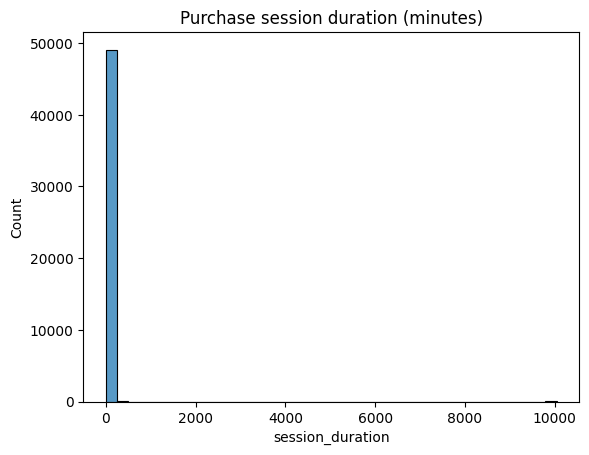

In [65]:
sns.histplot(
    df_purchase_sessions["session_duration"].dt.total_seconds()/60,
    bins=40
)

plt.title("Purchase session duration (minutes)")
plt.show()

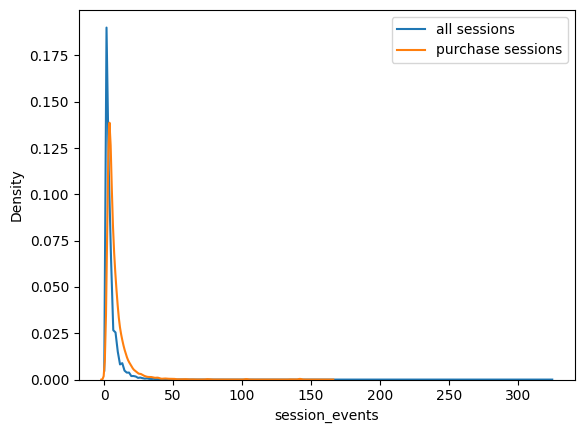

In [66]:
# Sessions normales vs sessions avec achat

sns.kdeplot(session_stats_full["session_events"], label="all sessions")
sns.kdeplot(df_purchase_sessions["session_events"], label="purchase sessions")

plt.legend()

## Session duration exploration (code not used yet, just to show outliers in session durations)

In [67]:
durations_sess = session_stats["session_duration"]

In [68]:
durations_sess.sort_values(ascending=False)

382126   0 days 17:59:49
179646   0 days 17:59:42
334273   0 days 17:58:48
398781   0 days 17:56:51
331147   0 days 17:55:58
               ...      
161127   0 days 00:00:00
356593   0 days 00:00:00
161126   0 days 00:00:00
161123   0 days 00:00:00
0        0 days 00:00:00
Name: session_duration, Length: 506055, dtype: timedelta64[ns]

In [69]:
durations_sess.describe()

count                       506055
mean     0 days 00:05:38.966410765
std      0 days 00:34:03.070192826
min                0 days 00:00:00
25%                0 days 00:00:00
50%                0 days 00:00:50
75%                0 days 00:03:33
max                0 days 17:59:49
Name: session_duration, dtype: object

In [70]:
crazy_duration = durations_sess[durations_sess > "1 days"]

In [71]:
crazy_duration
# A supprimer des prochaines itérations du modèle après baseline?

Series([], Name: session_duration, dtype: timedelta64[ns])

## Grouping Session features per user_id for the observation period(session_user df)

In [72]:
# INfos de session par user_ID sur l'intervalle d'observation

session_user = session_stats.groupby("user_id").agg(
    avg_session_duration    = ("session_duration", "mean"),
    median_session_duration = ("session_duration", "median"),
    max_session_duration    = ("session_duration", "max"),
    avg_events_per_session  = ("session_events", "mean"),
    max_events_per_session  = ("session_events", "max"),
)
session_user

,avg_session_duration,median_session_duration,max_session_duration,avg_events_per_session,max_events_per_session
user_id,,,,,
241587569,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
241784978,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
244951053,0 days 00:01:31,0 days 00:01:31,0 days 00:02:09,2.5,3
293335683,0 days 00:05:04.333333333,0 days 00:04:35,0 days 00:09:08,4.0,6
293957954,0 days 00:01:04,0 days 00:01:04,0 days 00:01:04,4.0,4
...,...,...,...,...,...
556879570,0 days 00:01:43,0 days 00:01:43,0 days 00:01:43,5.0,5
556879574,0 days 00:01:05,0 days 00:01:05,0 days 00:01:05,3.0,3
556879612,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1


# Features product diversity (diversity df)

In [73]:
diversity = X_obs.groupby("user_id").agg(
    unique_products   = ("product_id", "nunique"),
    unique_categories = ("category_id", "nunique"),
    unique_brands     = ("brand", "nunique"),
)

diversity["product_revisit_rate"] = 1 - (
    diversity["unique_products"] /
    behavior["total_events"].replace(0, 1)
)

In [74]:
diversity

,unique_products,unique_categories,unique_brands,product_revisit_rate
user_id,,,,
241587569,1,1,1,0.000000
241784978,1,1,1,0.000000
244951053,3,1,2,0.400000
293335683,3,1,1,0.750000
293957954,4,1,1,0.000000
...,...,...,...,...
556879570,3,1,2,0.400000
556879574,2,1,1,0.333333
556879612,1,1,1,0.000000


# Features de prix

In [75]:
price_feats = X_obs.groupby("user_id")["price"].agg(
    avg_price    = "mean",
    median_price = "median",
    max_price    = "max",
    min_price    = "min",
)

price_feats["price_range"] = price_feats["max_price"] - price_feats["min_price"]

In [76]:
price_feats

,avg_price,median_price,max_price,min_price,price_range
user_id,,,,,
241587569,130.250000,130.250000,130.250000,130.250000,0.000000
241784978,462.380005,462.380005,462.380005,462.380005,0.000000
244951053,759.712036,731.039978,1415.479980,460.500000,954.979980
293335683,529.153381,447.744995,720.460022,370.410004,350.050018
293957954,226.712494,236.144989,248.869995,185.690002,63.179993
...,...,...,...,...,...
556879570,214.893997,173.979996,462.410004,132.050003,330.359985
556879574,172.243332,132.050003,252.630005,132.050003,120.580002
556879612,252.630005,252.630005,252.630005,252.630005,0.000000


# Features temporelles

In [77]:
temporal = X_obs.groupby("user_id").agg(
    last_event_ts  = ("event_time", "max"),
    first_event_ts = ("event_time", "min"),
    preferred_hour = ("hour", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 12),
    weekend_ratio  = ("is_weekend", "mean"),
)

# Features grouping and final X, y

In [78]:
user_features = (behavior
                 .join(session_user, how="left")
                 .join(diversity, how="left")
                 .join(price_feats, how="left")
                 .join(temporal, how="left")
)

In [79]:
user_features

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio,...,product_revisit_rate,avg_price,median_price,max_price,min_price,price_range,last_event_ts,first_event_ts,preferred_hour,weekend_ratio
user_id,,,,,,,,,,,,,,,,,,,,,
241587569,1,1,0,0,1,1,0,0,0.0,0.0,...,0.000000,130.250000,130.250000,130.250000,130.250000,0.000000,2019-10-02 11:28:14,2019-10-02 11:28:14,11,0.0
241784978,1,1,0,0,1,1,0,0,0.0,0.0,...,0.000000,462.380005,462.380005,462.380005,462.380005,0.000000,2019-10-04 08:00:07,2019-10-04 08:00:07,8,0.0
244951053,5,5,0,0,2,2,0,0,0.0,0.0,...,0.400000,759.712036,731.039978,1415.479980,460.500000,954.979980,2019-10-03 03:08:27,2019-10-01 08:47:35,3,0.0
293335683,12,12,0,0,3,1,0,0,0.0,0.0,...,0.750000,529.153381,447.744995,720.460022,370.410004,350.050018,2019-10-02 18:00:33,2019-10-02 04:26:05,4,0.0
293957954,4,4,0,0,1,1,0,0,0.0,0.0,...,0.000000,226.712494,236.144989,248.869995,185.690002,63.179993,2019-10-02 12:49:52,2019-10-02 12:48:48,12,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
556879570,5,5,0,0,1,1,0,0,0.0,0.0,...,0.400000,214.893997,173.979996,462.410004,132.050003,330.359985,2019-10-04 23:59:55,2019-10-04 23:58:12,23,0.0
556879574,3,3,0,0,1,1,0,0,0.0,0.0,...,0.333333,172.243332,132.050003,252.630005,132.050003,120.580002,2019-10-04 23:59:34,2019-10-04 23:58:29,23,0.0
556879612,1,1,0,0,1,1,0,0,0.0,0.0,...,0.000000,252.630005,252.630005,252.630005,252.630005,0.000000,2019-10-04 23:59:11,2019-10-04 23:59:11,23,0.0


In [80]:
user_features.isna().sum()

total_events                 0
total_views                  0
total_carts                  0
total_purchases              0
n_sessions                   0
n_days_active                0
has_ever_carted              0
has_ever_purchased           0
view_to_cart_ratio           0
cart_to_purchase_ratio       0
avg_session_duration       663
median_session_duration    663
max_session_duration       663
avg_events_per_session     663
max_events_per_session     663
unique_products              0
unique_categories            0
unique_brands                0
product_revisit_rate         0
avg_price                    0
median_price                 0
max_price                    0
min_price                    0
price_range                  0
last_event_ts                0
first_event_ts               0
preferred_hour               0
weekend_ratio                0
dtype: int64

In [81]:
dataset = y_purchasers_x_obs.merge(user_features, on="user_id", how="inner")

In [82]:
dataset

,user_id,label,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,...,product_revisit_rate,avg_price,median_price,max_price,min_price,price_range,last_event_ts,first_event_ts,preferred_hour,weekend_ratio
0,550050854,0,7,7,0,0,1,1,0,0,...,0.285714,582.668579,580.890015,1512.780029,251.740005,1261.040039,2019-10-01 00:03:17,2019-10-01 00:00:01,0,0.0
1,535871217,0,10,10,0,0,2,1,0,0,...,0.600000,820.096985,614.530029,1747.790039,388.429993,1359.360107,2019-10-01 11:45:21,2019-10-01 00:00:04,11,0.0
2,537918940,0,4,4,0,0,1,1,0,0,...,0.250000,501.524994,514.130005,566.010010,411.829987,154.180023,2019-10-01 00:01:47,2019-10-01 00:00:11,0,0.0
3,530282093,0,1,1,0,0,1,1,0,0,...,0.000000,900.640015,900.640015,900.640015,900.640015,0.000000,2019-10-01 00:00:11,2019-10-01 00:00:11,0,0.0
4,537192226,0,1,1,0,0,1,1,0,0,...,0.000000,193.029999,193.029999,193.029999,193.029999,0.000000,2019-10-01 00:00:18,2019-10-01 00:00:18,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311289,521099214,0,3,2,1,0,1,1,1,0,...,0.666667,151.610001,151.610001,151.610001,151.610001,0.000000,2019-10-04 23:59:38,2019-10-04 23:59:11,23,0.0
311290,556879729,0,3,3,0,0,1,1,0,0,...,0.666667,380.690033,380.690002,380.690002,380.690002,0.000000,2019-10-04 23:59:52,2019-10-04 23:59:11,23,0.0
311291,556879612,0,1,1,0,0,1,1,0,0,...,0.000000,252.630005,252.630005,252.630005,252.630005,0.000000,2019-10-04 23:59:11,2019-10-04 23:59:11,23,0.0
311292,556872550,0,1,1,0,0,1,1,0,0,...,0.000000,334.630005,334.630005,334.630005,334.630005,0.000000,2019-10-04 23:59:53,2019-10-04 23:59:53,23,0.0


In [83]:
# Enlève les long_session_users du dataset avec le ~
dataset = dataset[~dataset["user_id"].isin(long_session_users["user_id"])]
dataset

,user_id,label,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,...,product_revisit_rate,avg_price,median_price,max_price,min_price,price_range,last_event_ts,first_event_ts,preferred_hour,weekend_ratio
0,550050854,0,7,7,0,0,1,1,0,0,...,0.285714,582.668579,580.890015,1512.780029,251.740005,1261.040039,2019-10-01 00:03:17,2019-10-01 00:00:01,0,0.0
1,535871217,0,10,10,0,0,2,1,0,0,...,0.600000,820.096985,614.530029,1747.790039,388.429993,1359.360107,2019-10-01 11:45:21,2019-10-01 00:00:04,11,0.0
2,537918940,0,4,4,0,0,1,1,0,0,...,0.250000,501.524994,514.130005,566.010010,411.829987,154.180023,2019-10-01 00:01:47,2019-10-01 00:00:11,0,0.0
3,530282093,0,1,1,0,0,1,1,0,0,...,0.000000,900.640015,900.640015,900.640015,900.640015,0.000000,2019-10-01 00:00:11,2019-10-01 00:00:11,0,0.0
4,537192226,0,1,1,0,0,1,1,0,0,...,0.000000,193.029999,193.029999,193.029999,193.029999,0.000000,2019-10-01 00:00:18,2019-10-01 00:00:18,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311289,521099214,0,3,2,1,0,1,1,1,0,...,0.666667,151.610001,151.610001,151.610001,151.610001,0.000000,2019-10-04 23:59:38,2019-10-04 23:59:11,23,0.0
311290,556879729,0,3,3,0,0,1,1,0,0,...,0.666667,380.690033,380.690002,380.690002,380.690002,0.000000,2019-10-04 23:59:52,2019-10-04 23:59:11,23,0.0
311291,556879612,0,1,1,0,0,1,1,0,0,...,0.000000,252.630005,252.630005,252.630005,252.630005,0.000000,2019-10-04 23:59:11,2019-10-04 23:59:11,23,0.0
311292,556872550,0,1,1,0,0,1,1,0,0,...,0.000000,334.630005,334.630005,334.630005,334.630005,0.000000,2019-10-04 23:59:53,2019-10-04 23:59:53,23,0.0


In [84]:
X = dataset.drop(columns="label")

In [85]:
X

,user_id,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,...,product_revisit_rate,avg_price,median_price,max_price,min_price,price_range,last_event_ts,first_event_ts,preferred_hour,weekend_ratio
0,550050854,7,7,0,0,1,1,0,0,0.0,...,0.285714,582.668579,580.890015,1512.780029,251.740005,1261.040039,2019-10-01 00:03:17,2019-10-01 00:00:01,0,0.0
1,535871217,10,10,0,0,2,1,0,0,0.0,...,0.600000,820.096985,614.530029,1747.790039,388.429993,1359.360107,2019-10-01 11:45:21,2019-10-01 00:00:04,11,0.0
2,537918940,4,4,0,0,1,1,0,0,0.0,...,0.250000,501.524994,514.130005,566.010010,411.829987,154.180023,2019-10-01 00:01:47,2019-10-01 00:00:11,0,0.0
3,530282093,1,1,0,0,1,1,0,0,0.0,...,0.000000,900.640015,900.640015,900.640015,900.640015,0.000000,2019-10-01 00:00:11,2019-10-01 00:00:11,0,0.0
4,537192226,1,1,0,0,1,1,0,0,0.0,...,0.000000,193.029999,193.029999,193.029999,193.029999,0.000000,2019-10-01 00:00:18,2019-10-01 00:00:18,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311289,521099214,3,2,1,0,1,1,1,0,0.5,...,0.666667,151.610001,151.610001,151.610001,151.610001,0.000000,2019-10-04 23:59:38,2019-10-04 23:59:11,23,0.0
311290,556879729,3,3,0,0,1,1,0,0,0.0,...,0.666667,380.690033,380.690002,380.690002,380.690002,0.000000,2019-10-04 23:59:52,2019-10-04 23:59:11,23,0.0
311291,556879612,1,1,0,0,1,1,0,0,0.0,...,0.000000,252.630005,252.630005,252.630005,252.630005,0.000000,2019-10-04 23:59:11,2019-10-04 23:59:11,23,0.0
311292,556872550,1,1,0,0,1,1,0,0,0.0,...,0.000000,334.630005,334.630005,334.630005,334.630005,0.000000,2019-10-04 23:59:53,2019-10-04 23:59:53,23,0.0


In [86]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 310186 entries, 0 to 311293
Data columns (total 29 columns):
 #   Column                   Non-Null Count   Dtype          
---  ------                   --------------   -----          
 0   user_id                  310186 non-null  int32          
 1   total_events             310186 non-null  int64          
 2   total_views              310186 non-null  int64          
 3   total_carts              310186 non-null  int64          
 4   total_purchases          310186 non-null  int64          
 5   n_sessions               310186 non-null  int64          
 6   n_days_active            310186 non-null  int64          
 7   has_ever_carted          310186 non-null  int8           
 8   has_ever_purchased       310186 non-null  int8           
 9   view_to_cart_ratio       310186 non-null  float64        
 10  cart_to_purchase_ratio   310186 non-null  float64        
 11  avg_session_duration     310186 non-null  timedelta64[ns]
 12  median_

In [87]:
timedelta_cols = X.select_dtypes(include=['timedelta64']).columns

for col in timedelta_cols:
    X[col] = X[col].dt.total_seconds()


In [88]:
X = X.drop(columns="user_id")

In [89]:
X

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio,...,product_revisit_rate,avg_price,median_price,max_price,min_price,price_range,last_event_ts,first_event_ts,preferred_hour,weekend_ratio
0,7,7,0,0,1,1,0,0,0.0,0.0,...,0.285714,582.668579,580.890015,1512.780029,251.740005,1261.040039,2019-10-01 00:03:17,2019-10-01 00:00:01,0,0.0
1,10,10,0,0,2,1,0,0,0.0,0.0,...,0.600000,820.096985,614.530029,1747.790039,388.429993,1359.360107,2019-10-01 11:45:21,2019-10-01 00:00:04,11,0.0
2,4,4,0,0,1,1,0,0,0.0,0.0,...,0.250000,501.524994,514.130005,566.010010,411.829987,154.180023,2019-10-01 00:01:47,2019-10-01 00:00:11,0,0.0
3,1,1,0,0,1,1,0,0,0.0,0.0,...,0.000000,900.640015,900.640015,900.640015,900.640015,0.000000,2019-10-01 00:00:11,2019-10-01 00:00:11,0,0.0
4,1,1,0,0,1,1,0,0,0.0,0.0,...,0.000000,193.029999,193.029999,193.029999,193.029999,0.000000,2019-10-01 00:00:18,2019-10-01 00:00:18,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311289,3,2,1,0,1,1,1,0,0.5,0.0,...,0.666667,151.610001,151.610001,151.610001,151.610001,0.000000,2019-10-04 23:59:38,2019-10-04 23:59:11,23,0.0
311290,3,3,0,0,1,1,0,0,0.0,0.0,...,0.666667,380.690033,380.690002,380.690002,380.690002,0.000000,2019-10-04 23:59:52,2019-10-04 23:59:11,23,0.0
311291,1,1,0,0,1,1,0,0,0.0,0.0,...,0.000000,252.630005,252.630005,252.630005,252.630005,0.000000,2019-10-04 23:59:11,2019-10-04 23:59:11,23,0.0
311292,1,1,0,0,1,1,0,0,0.0,0.0,...,0.000000,334.630005,334.630005,334.630005,334.630005,0.000000,2019-10-04 23:59:53,2019-10-04 23:59:53,23,0.0


In [90]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 310186 entries, 0 to 311293
Data columns (total 28 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   total_events             310186 non-null  int64         
 1   total_views              310186 non-null  int64         
 2   total_carts              310186 non-null  int64         
 3   total_purchases          310186 non-null  int64         
 4   n_sessions               310186 non-null  int64         
 5   n_days_active            310186 non-null  int64         
 6   has_ever_carted          310186 non-null  int8          
 7   has_ever_purchased       310186 non-null  int8          
 8   view_to_cart_ratio       310186 non-null  float64       
 9   cart_to_purchase_ratio   310186 non-null  float64       
 10  avg_session_duration     310186 non-null  float64       
 11  median_session_duration  310186 non-null  float64       
 12  max_session_duration 

In [91]:
datetime_cols = X.select_dtypes(include=['datetime64']).columns
print(datetime_cols)

for col in datetime_cols:
    X[col] = X[col].astype('int64') / 10**9

Index(['last_event_ts', 'first_event_ts'], dtype='object')


In [92]:
y = dataset["label"]
y

0         0
1         0
2         0
3         0
4         0
         ..
311289    0
311290    0
311291    0
311292    0
311293    0
Name: label, Length: 310186, dtype: int64

# Model v1 (baseline) and Train test split 

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [94]:
X_test

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio,...,product_revisit_rate,avg_price,median_price,max_price,min_price,price_range,last_event_ts,first_event_ts,preferred_hour,weekend_ratio
252057,3,3,0,0,1,1,0,0,0.000000,0.0,...,0.333333,1083.056641,348.119995,2552.929932,348.119995,2204.810059,1.570174e+09,1.570172e+09,6,0.0
238499,6,6,0,0,1,1,0,0,0.000000,0.0,...,0.000000,1295.734985,1306.854980,1776.109985,849.419983,926.690002,1.570156e+09,1.570156e+09,2,0.0
9279,1,1,0,0,1,1,0,0,0.000000,0.0,...,0.000000,130.759995,130.759995,130.759995,130.759995,0.000000,1.569904e+09,1.569904e+09,4,0.0
149692,2,2,0,0,2,1,0,0,0.000000,0.0,...,0.000000,646.400024,646.400024,706.309998,586.489990,119.820007,1.570030e+09,1.570030e+09,15,0.0
54712,15,14,1,0,6,4,1,0,0.071429,0.0,...,0.466667,157.714661,35.779999,1747.790039,17.340000,1730.450073,1.570190e+09,1.569935e+09,2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61695,4,4,0,0,2,1,0,0,0.000000,0.0,...,0.750000,254.190002,254.190002,254.190002,254.190002,0.000000,1.569940e+09,1.569939e+09,14,0.0
198853,1,1,0,0,1,1,0,0,0.000000,0.0,...,0.000000,975.570007,975.570007,975.570007,975.570007,0.000000,1.570098e+09,1.570098e+09,10,0.0
243993,18,18,0,0,1,1,0,0,0.000000,0.0,...,0.388889,140.588898,109.514999,257.119995,99.830002,157.289993,1.570164e+09,1.570164e+09,4,0.0
282519,14,14,0,0,1,1,0,0,0.000000,0.0,...,0.142857,570.129272,593.359985,1415.479980,132.050003,1283.429932,1.570196e+09,1.570195e+09,13,0.0


In [95]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
base_spw = neg / pos
base_spw
# Combien de fois les non acheteurs sont présents de plus que les acheteurs

np.float64(8.818699798203616)

In [96]:
model_lgbm = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,
    scale_pos_weight=base_spw,
    random_state=42,
    verbosity=-1,
    n_jobs=-1,
)

In [97]:
model_lgbm.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [98]:
y_test_proba = model_lgbm.predict_proba(X_test)[:, 1]

y_test_pred  = (y_test_proba >= 0.5).astype(int)
#Permet d'ajuster le seuil de probabilité de classification

roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc  = average_precision_score(y_test, y_test_proba)

In [99]:
roc_auc


1.0

In [100]:
pr_auc

1.0

In [101]:
recall = recall_score(y_test, y_test_pred)
recall

1.0

# Model v1 - Added Standardisation (lower performances! Not reused for model V2)

In [102]:
pipeline = make_pipeline(
    StandardScaler(),
    model_lgbm
)

pipeline.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('lgbmclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1


In [103]:
y_test_proba = pipeline.predict_proba(X_test)[:, 1]


/Users/adrien/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [104]:
roc_auc = roc_auc_score(y_test, y_test_proba)

In [105]:
roc_auc


1.0

In [106]:
pr_auc = average_precision_score(y_test, y_test_proba)

In [107]:
pr_auc


1.0

## Model v1 - Learning Curves PR AUC standardized

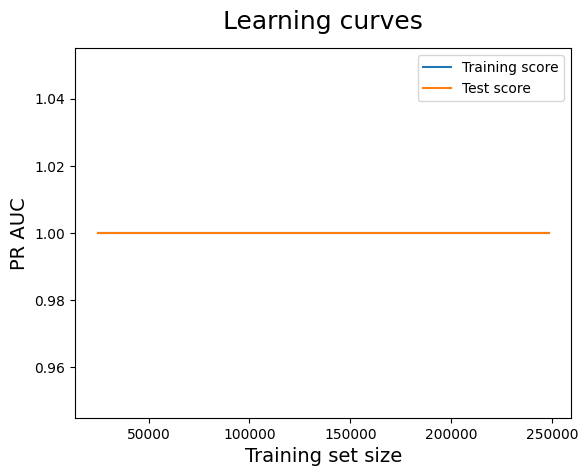

In [108]:
train_sizes, train_scores, val_scores = learning_curve(
    model_lgbm,
    X,
    y,
    cv=5,
    scoring="average_precision",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)


# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(val_scores, axis=1)

plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylabel('PR AUC', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()

# Model_v2 - Grid Search for best hyperparameters

In [109]:
from sklearn.model_selection import RandomizedSearchCV


In [110]:
param_dist = {
    "n_estimators": np.arange(100, 600, 100),
    "learning_rate": np.linspace(0.01, 0.2, 20),
    "num_leaves": np.arange(20, 150, 10),
    "max_depth": [-1, 5, 10, 15]
}

search = RandomizedSearchCV(
    model_lgbm,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="average_precision",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print(search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'num_leaves': np.int64(40), 'n_estimators': np.int64(200), 'max_depth': 5, 'learning_rate': np.float64(0.04)}


# Model V2 with GridSearch best hyperparams (Best model to date)

In [111]:
model_lgbm_v2 = lgb.LGBMClassifier(
    objective="binary",
    scale_pos_weight=base_spw,
    random_state=42,
    verbosity=-1,
    n_jobs=-1,
    num_leaves=40,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.04
)

In [112]:
model_lgbm_v2.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,40
,max_depth,5
,learning_rate,0.04
,n_estimators,200
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [113]:
y_test_proba_2 = model_lgbm_v2.predict_proba(X_test)[:, 1]
y_test_pred_2  = (y_test_proba_2 >= 0.5).astype(int)

In [114]:
roc_auc_2 = roc_auc_score(y_test, y_test_proba_2)
pr_auc_2  = average_precision_score(y_test, y_test_proba_2)

In [115]:
roc_auc_2

1.0

In [116]:
pr_auc_2

1.0

In [117]:
recall_2 = recall_score(y_test, y_test_pred_2)
recall_2

1.0

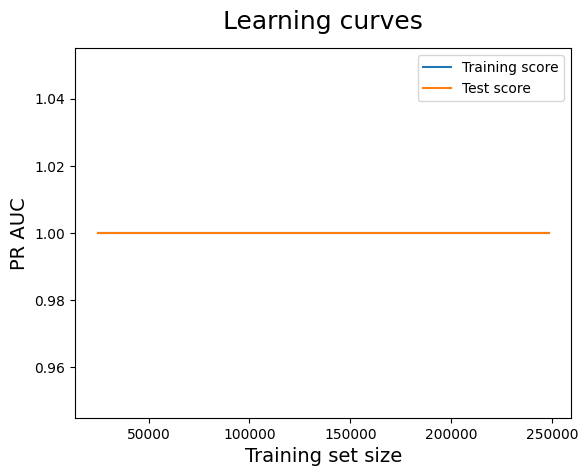

In [118]:
train_sizes, train_scores, val_scores = learning_curve(
    model_lgbm_v2,
    X,
    y,
    cv=5,
    scoring="average_precision",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)


# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(val_scores, axis=1)

plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylabel('PR AUC', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()

In [119]:
y_pred = model_lgbm_v2.predict(X_test)

print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))



Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55720
           1       1.00      1.00      1.00      6318

    accuracy                           1.00     62038
   macro avg       1.00      1.00      1.00     62038
weighted avg       1.00      1.00      1.00     62038


Confusion matrix:
[[55720     0]
 [    0  6318]]
